# Minor Project: Unsupervised Learning
## Credit Card Fraud Detection

## 1. Problem Understanding

### What is Fraud Detection?

Fraud detection is the process of identifying transactions that may be unauthorized or suspicious.

### Why is Fraud Detection Difficult?

Fraudulent transactions are rare compared to normal transactions. Fraud labels may also be delayed, incomplete, or unavailable.

### Why Use Unsupervised Learning?

Unsupervised learning can identify unusual transaction patterns without using fraud labels while building the model. The actual fraud label can be used later for evaluation.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

In [23]:
df = pd.read_csv("creditcard.csv")

In [24]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [25]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


In [26]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [28]:
print("Missing values:")
print(df.isnull().sum().sum())

Missing values:
0


In [29]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


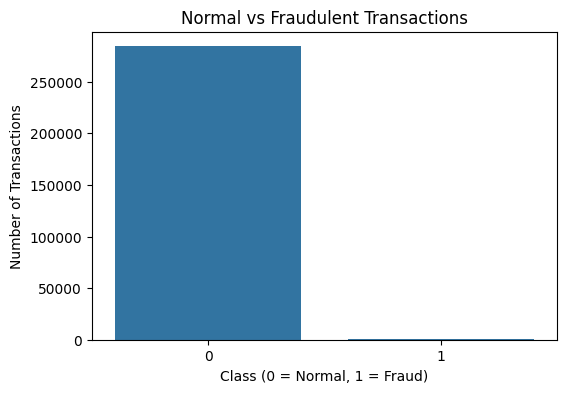

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [31]:
print(df["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


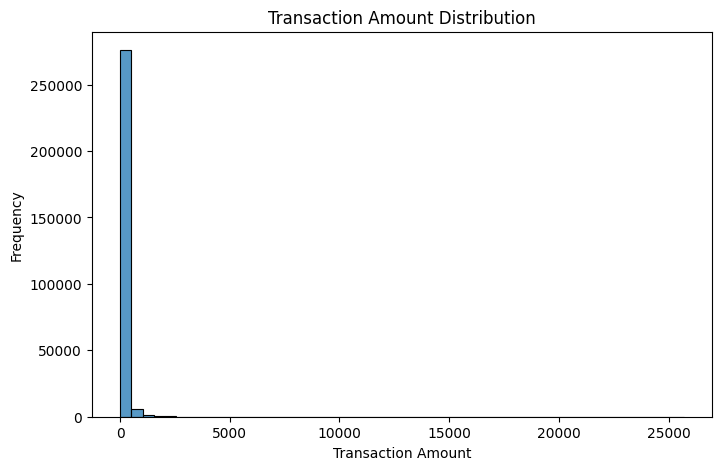

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

### EDA Insights

- The dataset contains a very large number of normal transactions compared to fraudulent transactions.
- The class distribution is highly imbalanced.
- Transaction amounts vary considerably across the dataset.
- The imbalance in the target class makes fraud detection challenging and supports the use of anomaly detection techniques.

## 3. Data Preprocessing

In [33]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (284807, 30)
Label shape: (284807,)


In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (284807, 30)


### Preprocessing Justification

The `Class` column is separated from the features because it represents the actual fraud label. It is not used during model building, following the unsupervised learning requirement.

The remaining transaction features are scaled using StandardScaler so that features with different numerical ranges do not dominate the analysis. The scaled features are then used for clustering and anomaly detection.

## 4. Clustering Approach

### Method Selection

K-Means Clustering is selected to group transactions into clusters based on similarity in their feature values. It provides a simple way to identify different transaction patterns without using the fraud label.

In [35]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("Number of clusters:", len(set(kmeans_labels)))

Number of clusters: 2


In [36]:
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print("Transactions in each cluster:")
print(cluster_counts)

Transactions in each cluster:
0    154550
1    130257
Name: count, dtype: int64


### Parameter Tuning Logic

Two clusters were selected as an initial clustering approach because the problem broadly involves separating normal transaction patterns from potentially unusual transaction patterns. The `random_state` is fixed to 42 to make the results reproducible, and `n_init=10` allows K-Means to run with multiple centroid initializations.

### Cluster Interpretation

The K-Means algorithm divides the transactions into two groups based on similarity in their scaled feature values. The clusters represent different transaction patterns. However, the clusters cannot directly be considered as normal or fraudulent because the fraud label was not used during clustering.

## 5. Anomaly Detection Approach

### Model Selection

Isolation Forest is selected because it is specifically designed to identify unusual observations in a dataset. It works by isolating observations that are different from the majority of the data.

In [37]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.001,
    random_state=42
)

iso_predictions = iso_forest.fit_predict(X_scaled)

print("Isolation Forest predictions created successfully.")

Isolation Forest predictions created successfully.


In [38]:
anomaly_labels = np.where(iso_predictions == -1, 1, 0)

print("Normal transactions:", (anomaly_labels == 0).sum())
print("Anomalous transactions:", (anomaly_labels == 1).sum())

Normal transactions: 284522
Anomalous transactions: 285


### Parameter Decisions

The Isolation Forest model uses 100 trees to build the anomaly detection model. A contamination value of 0.001 is used to specify a small expected proportion of anomalies because fraudulent transactions are rare in the dataset. The random state is fixed at 42 to make the results reproducible.

### Output Interpretation

Isolation Forest assigns each transaction as either a normal observation or an anomaly. The anomalous transactions are considered potentially suspicious because they differ from the majority of observations. These anomalies are not automatically treated as fraud because the actual fraud label was not used during model building.

## 6. Comparison of Methods

K-Means Clustering groups transactions based on similarity, while Isolation Forest identifies observations that appear unusual.

The number of transactions identified by each method is compared below.

In [39]:
kmeans_anomaly_cluster = cluster_counts.idxmin()

kmeans_anomalies = (kmeans_labels == kmeans_anomaly_cluster).sum()

print("K-Means potentially unusual transactions:", kmeans_anomalies)
print("Isolation Forest anomalous transactions:", (anomaly_labels == 1).sum())

K-Means potentially unusual transactions: 130257
Isolation Forest anomalous transactions: 285


In [40]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "Isolation Forest"],
    "Potential Anomalies": [
        kmeans_anomalies,
        (anomaly_labels == 1).sum()
    ]
})

comparison

,Method,Potential Anomalies
0,K-Means,130257
1,Isolation Forest,285


### Comparison and Interpretation

K-Means identifies groups of similar transactions, whereas Isolation Forest is specifically designed to detect unusual observations.

The number of potentially unusual transactions differs between the two methods because they use different approaches. K-Means focuses on clustering similarity, while Isolation Forest focuses on isolating observations that are different from the majority.

K-Means is useful for understanding transaction groups, while Isolation Forest is more directly suited to anomaly detection.

## 7. Bonus Evaluation

The actual `Class` label is used only at this stage to evaluate the anomaly detection results. It was not used during model building.

In [41]:
cm = confusion_matrix(y, anomaly_labels)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y, anomaly_labels, target_names=["Normal", "Fraud"]))

Confusion Matrix:
[[284113    202]
 [   409     83]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.29      0.17      0.21       492

    accuracy                           1.00    284807
   macro avg       0.64      0.58      0.61    284807
weighted avg       1.00      1.00      1.00    284807



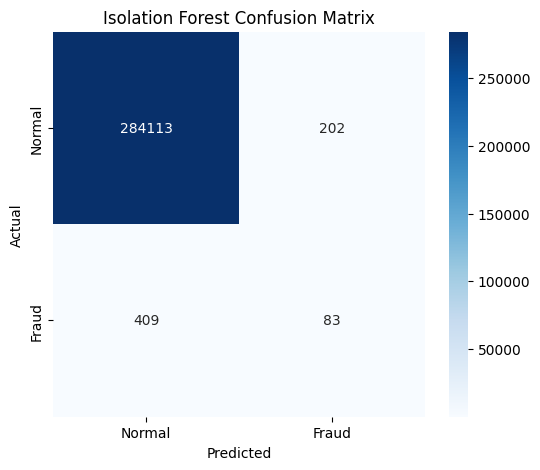

In [42]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Evaluation

The confusion matrix compares the Isolation Forest predictions with the actual fraud labels. Precision measures how many transactions predicted as fraud were actually fraudulent, while recall measures how many actual fraudulent transactions were detected.

Isolation Forest is evaluated using precision, recall, and the confusion matrix to understand its effectiveness in identifying fraudulent transactions.

## 8. Final Conclusion

### Business Perspective

Credit card fraud is difficult to detect because fraudulent transactions are rare and may not always be labelled. Unsupervised learning can help identify unusual transaction patterns without depending on fraud labels during model building.

### Recommendation

K-Means is useful for understanding groups of similar transactions, while Isolation Forest is more suitable for identifying unusual transactions. Based on the anomaly detection approach and evaluation results, Isolation Forest is recommended as the more suitable method for detecting potentially fraudulent transactions.

### Final Summary

This project demonstrated an unsupervised approach to credit card fraud detection using K-Means Clustering and Isolation Forest. The methods were compared based on the anomalies they identified, and Isolation Forest was evaluated using the actual fraud labels.